# **Labour Market Exploratory Data Analysis (EDA) Dashboard**

**Labour Market EDA Dashboard:** The primary objective of this project is to conduct a comprehensive Exploratory Data Analysis (EDA) on the Nigerian Labour Force Statistics dataset. The goal is to identify key trends, patterns, and anomalies,concerning employment, unemployment, and workforce composition  culminating in a visually compelling dashboard and a concise narrative summary that highlights critical insights for business leaders and policymakers.

## **Data Acquisition & Preprocessing**


In [1]:
#importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
#Mounting my drive for file access
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### **Dataset**

In [3]:
#Loading dataset
file_path='/content/drive/MyDrive/Caasitech Academy/AI Training Cameroon/Week 1/dataset_nlfs_2024q3_indiv.dta'
df=pd.read_stata(file_path)

In [4]:
#Create a copy of data set to manipulate
data=df.copy()
# Preview data
print(data.head())
print(data.shape)

  interview_key    id1_zone id2_state    id3_lga id4b_ea id5_sector  \
0   84-85-56-47  NORTH WEST    SOKOTO  GWADABAWA   46200      RURAL   
1   84-85-56-47  NORTH WEST    SOKOTO  GWADABAWA   46200      RURAL   
2   84-85-56-47  NORTH WEST    SOKOTO  GWADABAWA   46200      RURAL   
3   84-85-56-47  NORTH WEST    SOKOTO  GWADABAWA   46200      RURAL   
4   84-85-56-47  NORTH WEST    SOKOTO  GWADABAWA   46200      RURAL   

  id6_cluster  id7a_structure  id7_hhnumber  hhroster_id  ...  um13 um14 um15  \
0           1               2             1            1  ...   NaN  NaN  NaN   
1           1               2             1            2  ...   NaN  NaN  NaN   
2           1               2             1            3  ...   NaN  NaN  NaN   
3           1               2             1            4  ...   NaN  NaN  NaN   
4           1               2             1            5  ...   NaN  NaN  NaN   

  um15ots um16 um16ots       sample  eatarget iscoisicmerge interviewstartdate  
0    

### **Data Integrity Audit**

**1. Null Value & Datatype Analysis**

In [5]:
#Define some important columns to investigate
important_cols = [
    'id1_zone','id2_state', 'id3_lga',
    'id5_sector', #Urban or rural sector
    'dc3',  # gender
    'dc5',  # age
    'dc6',  # marital status
    'ed6',   # highest education level
    'ed7',    # highest qualification obtained
    'um1_1', 'um1_2',  # unemployment indicators
    'atw1', 'atw2',   # employment indicators
    'interviewdate',#date of survey
    'popw' #population weight rescaled
]
#Creating a data set copy with selected columns
im_data = data[important_cols]

#Renaming columns
im_data = im_data.rename(columns={
    'id1_zone': 'zone',
    'id2_state': 'state',
    'id3_lga': 'lga',
    'id5_sector': 'sector',
    'dc3': 'gender',
    'dc5': 'age',
    'dc6': 'marital_status',
    'um1_1': 'job_search',
    'um1_2': 'business_start',
    'atw1': 'worked_for_pay',
    'atw2': 'self_employed',
    'ed6': 'education_level',
    'ed7': 'qualification'
})

#Check for datatypes
print (im_data.dtypes)

zone                     category
state                    category
lga                      category
sector                   category
gender                   category
age                          int8
marital_status           category
education_level          category
qualification            category
job_search               category
business_start           category
worked_for_pay           category
self_employed            category
interviewdate      datetime64[ns]
popw                      float32
dtype: object


In [6]:
#Check for columns with missing values amongst the identified important columns
important_missing = im_data.isnull().sum().sort_values(ascending=False)
print(important_missing)


job_search         27807
business_start     27803
marital_status     15301
self_employed       9031
qualification       7511
education_level     7511
worked_for_pay      5955
age                    0
gender                 0
sector                 0
lga                    0
zone                   0
state                  0
interviewdate          0
popw                   0
dtype: int64


In [7]:
# Checking for the unique categories that exist in the columns with missing data (all categorical colums)
for col in ['job_search', 'business_start','worked_for_pay', 'self_employed','education_level','marital_status','qualification']:
    unique_values = im_data[col].unique()
    print(f"Unique values in {col}: {unique_values}")

Unique values in job_search: [NaN, 'NO', 'YES']
Categories (2, object): ['NO' < 'YES']
Unique values in business_start: [NaN, 'NO', 'YES']
Categories (2, object): ['NO' < 'YES']
Unique values in worked_for_pay: ['NO', NaN, 'YES']
Categories (2, object): ['YES' < 'NO']
Unique values in self_employed: ['YES', 'NO', NaN]
Categories (2, object): ['YES' < 'NO']
Unique values in education_level: ['QUARANIC', NaN, 'P6', 'INTEGRATED ISLAMIC EDUCATION (ISLAMIYYA, TSAN..., 'NONE', ..., 'LOWER 6', 'BASIC LITERACY PROGRAM', 'TERTIARY VOCATIONAL/TECHNICAL/COMMERCIAL', 'UPPER 6', 'MODERN SCHOOL']
Length: 39
Categories (38, object): ['NONE' < 'N1' < 'N2' < 'PRE-NURSERY' < ... <
                          'UNIVERSITY - LEVELS 100, 200 OR 300' < 'UNIVERSITY - 400 LEVEL' < 'UNIVERSITY - 500 LEVEL' <
                          'UNIVERSITY - 600 LEVEL']
Unique values in marital_status: ['MARRIED (POLYGAMOUS)', 'NEVER MARRIED', NaN, 'MARRIED (MONOGAMOUS)', 'DIVORCED', 'WIDOWED', 'SEPARATED', 'INFORMAL/LOOSE 

In [8]:
# Dealing with missing values

# --- Unemployment related missing values  ---(assume values are missing because does not apply to person)
for col in ['job_search', 'business_start']:
    im_data[col] = im_data[col].fillna('NO')

# --- Employment related missing values ---(assume values are missing because does not apply to person)
for col in ['worked_for_pay', 'self_employed']:
    im_data[col] = im_data[col].fillna('NO')

# --- Education related missing values ---(Fill with unknown)
# Add 'Unknown' to categories before filling NaN
im_data['education_level'] = im_data['education_level'].cat.add_categories('Unknown')
im_data['education_level'] = im_data['education_level'].fillna('Unknown')

im_data['qualification'] = im_data['qualification'].cat.add_categories('Unknown')
im_data['qualification'] = im_data['qualification'].fillna('Unknown')

# --- Marital Status related missing values---(Fill with unknown)
im_data['marital_status'] = im_data['marital_status'].cat.add_categories('Unknown')
im_data['marital_status'] = im_data['marital_status'].fillna('Unknown')

In [9]:
#confirming no missing values
#Check for columns with missing values amongst the identified important columns
important_missing = im_data.isnull().sum().sort_values(ascending=False)
print(important_missing)
print (im_data.dtypes)

zone               0
state              0
lga                0
sector             0
gender             0
age                0
marital_status     0
education_level    0
qualification      0
job_search         0
business_start     0
worked_for_pay     0
self_employed      0
interviewdate      0
popw               0
dtype: int64
zone                     category
state                    category
lga                      category
sector                   category
gender                   category
age                          int8
marital_status           category
education_level          category
qualification            category
job_search               category
business_start           category
worked_for_pay           category
self_employed            category
interviewdate      datetime64[ns]
popw                      float32
dtype: object


**2. Duplicate Records**

In [10]:
#Check for duplicates in data
duplicates = im_data.duplicated().sum()
print("Duplicates:", duplicates)

#Drop duplicates from data
im_data = im_data.drop_duplicates()

Duplicates: 594


**3. Consistency Checks**

In [11]:
# AGE VALIDITY CHECK
# Age should be realistic (10–100; 10 chosen as the lower bound on the assumption that children under 10 cannot be working)
invalid_age = im_data[(im_data['age'] < 10) | (im_data['age'] > 100)]
print("Invalid age records:", len(invalid_age))


Invalid age records: 12435


In [12]:
#Drop entries with participant ages out of range defined above
im_data = im_data[(im_data['age'] >= 10) & (im_data['age'] <=100)]

## **Exploratory Data Analysis(EDA)**

**1. Descriptive Statistics**

In [13]:
print(im_data['age'].describe())

count    30926.000000
mean        30.759232
std         17.373887
min         10.000000
25%         16.000000
50%         27.000000
75%         42.000000
max        100.000000
Name: age, dtype: float64


**2. Distribution Analysis**

In [14]:
# Define employment status
def classify_status(row):
   if (row['worked_for_pay'] == 'YES') or (row['self_employed'] == 'YES') :
        return 'Employed'
   else :
        return 'Unemployed'

im_data['employment_status'] = im_data.apply(classify_status, axis=1)
employment_weighted = im_data.groupby('employment_status')['popw'].sum()
print(employment_weighted)

#print(im_data['employment_status'].value_counts())

employment_status
Employed      80507320.0
Unemployed    69529968.0
Name: popw, dtype: float32


In [15]:
#worked for pay vs self employed employment status
total_employed_count = len(im_data[im_data['employment_status'] == 'Employed'])

# Percentage of employed who worked for pay
employed_and_worked_for_pay = im_data[(im_data['employment_status'] == 'Employed') & (im_data['worked_for_pay'] == 'YES')]
Recruited_percent = (len(employed_and_worked_for_pay) / total_employed_count) * 100 if total_employed_count > 0 else 0

# Percentage of employed who are not "working for pay" (ie they are not recruited)
# This assumes that if they are 'Employed' and not 'worked_for_pay'=='YES', they must be 'self_employed'=='YES'
employed_not_worked_for_pay = im_data[(im_data['employment_status'] == 'Employed') & (im_data['worked_for_pay'] == 'NO')]
Self_Employed_Percent = (len(employed_not_worked_for_pay) / total_employed_count) * 100 if total_employed_count > 0 else 0

print("Percentage of employed that are recruited:", Recruited_percent)
print("Percentage of employed that are self-employed:", Self_Employed_Percent)


Percentage of employed that are recruited: 16.93955366154536
Percentage of employed that are self-employed: 83.06044633845464


In [16]:
# DISTRIBUTION ANALYSIS (TABLES)

print("\n Gender Distribution:")
print(im_data['gender'].value_counts(normalize=True) * 100)

print("\n Sector Distribution (Urban vs Rural):")
print(im_data['sector'].value_counts(normalize=True) * 100)

print("\n Marital Status Distribution:")
print(im_data['marital_status'].value_counts(normalize=True) * 100)



 Gender Distribution:
gender
FEMALE    50.410658
MALE      49.589342
Name: proportion, dtype: float64

 Sector Distribution (Urban vs Rural):
sector
URBAN    51.762271
RURAL    48.237729
Name: proportion, dtype: float64

 Marital Status Distribution:
marital_status
NEVER MARRIED           39.174158
MARRIED (MONOGAMOUS)    37.767574
MARRIED (POLYGAMOUS)     8.643213
Unknown                  7.951238
WIDOWED                  4.468732
SEPARATED                1.154368
DIVORCED                 0.423592
INFORMAL/LOOSE UNION     0.417125
Name: proportion, dtype: float64


**3. Unemployment Trends**

In [17]:
# Unemployment by gender
print("\n Unemployment by Gender:")
unemp_gender = (
    im_data[im_data['employment_status'] == 'Unemployed']
    .groupby('gender')['popw']
    .sum())
print(unemp_gender)


# Unemployment by sector
unemp_sector=(im_data[im_data['employment_status'] == 'Unemployed']
    .groupby('sector')['popw']
    .sum())
print(unemp_sector)


 Unemployment by Gender:
gender
MALE      34222624.0
FEMALE    35307344.0
Name: popw, dtype: float32
sector
URBAN    41405084.0
RURAL    28124888.0
Name: popw, dtype: float32


/tmp/ipykernel_1220/3203518724.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('gender')['popw']
/tmp/ipykernel_1220/3203518724.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('sector')['popw']


**4. Top 10 States by Unemployment**

In [18]:
top_states = (
    im_data[im_data['employment_status'] == 'Unemployed']
    .groupby('state')['popw']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\n Top 10 States by Unemployment:")
print(top_states)


 Top 10 States by Unemployment:
state
LAGOS      5517059.50
KANO       4221161.50
KADUNA     3348791.50
RIVERS     3180845.25
KATSINA    2803148.25
OGUN       2558640.00
OYO        2287748.00
BAUCHI     2278360.00
IMO        2244231.25
ANAMBRA    2227727.25
Name: popw, dtype: float32


/tmp/ipykernel_1220/1667557827.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('state')['popw']


**5.Youth Unemployment**

In [19]:
# Youth unemployment (18 < age < 35)
youth_unemp = im_data[(im_data['age'] > 18) & (im_data['age'] < 35) & (im_data['employment_status'] == 'Unemployed')]
youth_pop = im_data[(im_data['age'] > 18) & (im_data['age'] < 35)]

youth_unemp_weight = youth_unemp['popw'].sum()
youth_pop_weight = youth_pop['popw'].sum()
youth_unemployment_rate = (youth_unemp_weight / youth_pop_weight) * 100

print("Weighted Youth Unemployment Rate:", youth_unemployment_rate)
print('Unemployed Youths are about:',youth_unemp_weight)

Weighted Youth Unemployment Rate: 37.606785
Unemployed Youths are about: 15318943.0


## **Data Visualization**

In [20]:
#Create folder to save charts in
import os
os.makedirs('images', exist_ok=True)

In [21]:
# Total population weight (used for percentages where needed)
total_pop = im_data['popw'].sum()

/tmp/ipykernel_1220/2166671753.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=employment_status_weighted.index, y=employment_status_weighted.values, palette='Set2', ax=axes[0])
/tmp/ipykernel_1220/2166671753.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot_data, x='Category', y='Percentage', palette='viridis', ax=axes[1])


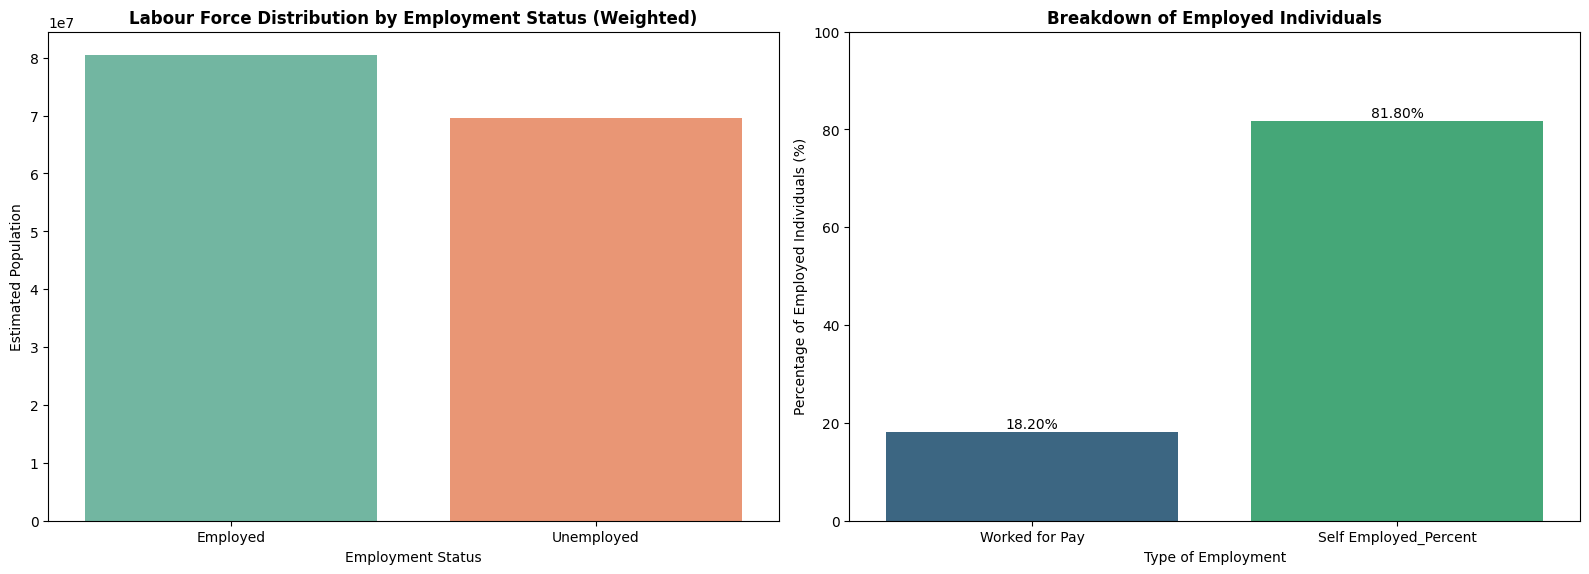

In [22]:
#1. Employment Status Distribution

total_employed_weight = im_data[im_data['employment_status'] == 'Employed']['popw'].sum()

worked_for_pay_weight = im_data[
    (im_data['employment_status'] == 'Employed') &
    (im_data['worked_for_pay'] == 'YES')
]['popw'].sum()

self_employed_weight = im_data[
    (im_data['employment_status'] == 'Employed') &
    (im_data['worked_for_pay'] == 'NO')
]['popw'].sum()

Recruited_percent = (worked_for_pay_weight / total_employed_weight) * 100
Self_Employed_Percent = (self_employed_weight / total_employed_weight) * 100

employment_status_weighted = im_data.groupby('employment_status')['popw'].sum()


#Split plot to show general employment status on one side, and the percentage of those employed that are recruited on the other side of the chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6)) # Create a figure with 2 subplots

# Plot 1: General Employment Status Distribution
sns.barplot(x=employment_status_weighted.index, y=employment_status_weighted.values, palette='Set2', ax=axes[0])
axes[0].set_title("Labour Force Distribution by Employment Status (Weighted)", weight='bold')
axes[0].set_xlabel("Employment Status")
axes[0].set_ylabel("Estimated Population")

# Plot 2: Percentage of Employed by Type of Work (Recruited vs. Self Employed_Percent)
plot_data = pd.DataFrame({
    'Category': ['Worked for Pay', 'Self Employed_Percent'],
    'Percentage': [Recruited_percent, Self_Employed_Percent]
})
sns.barplot(data=plot_data, x='Category', y='Percentage', palette='viridis', ax=axes[1])
axes[1].set_title("Breakdown of Employed Individuals", weight='bold')
axes[1].set_xlabel("Type of Employment")
axes[1].set_ylabel("Percentage of Employed Individuals (%)")
axes[1].set_ylim(0, 100) # Ensure y-axis goes from 0 to 100 for a percentage

# Add the percentage value as text on the bar
for container in axes[1].containers:
    axes[1].bar_label(container, fmt='%.2f%%')

plt.tight_layout()
plt.savefig('images/chart1_employment_status_and_employment_type_breakdown.png', dpi=300, bbox_inches='tight')
plt.show()

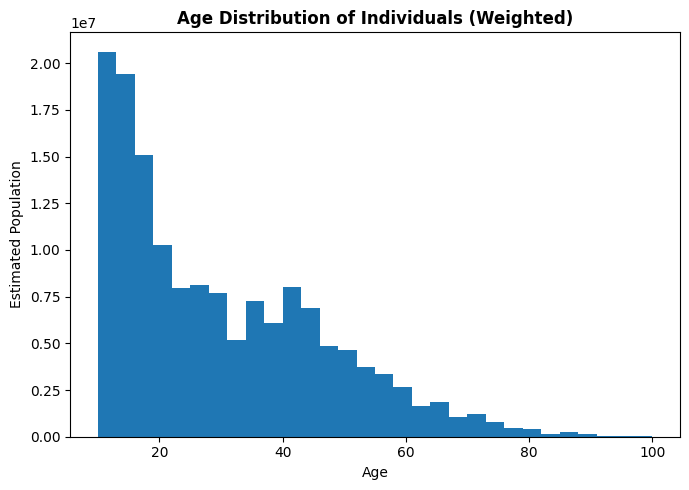

In [23]:
#2. Age distribution histogram
plt.figure(figsize=(7,5))
plt.hist(im_data['age'], bins=30, weights=im_data['popw'])
plt.title('Age Distribution of Individuals (Weighted)', weight='bold')
plt.xlabel('Age')
plt.ylabel('Estimated Population')
plt.tight_layout()
plt.savefig('images/chart2_age_distribution_weighted.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1220/945406899.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  gender_weighted = im_data.groupby('gender')['popw'].sum()


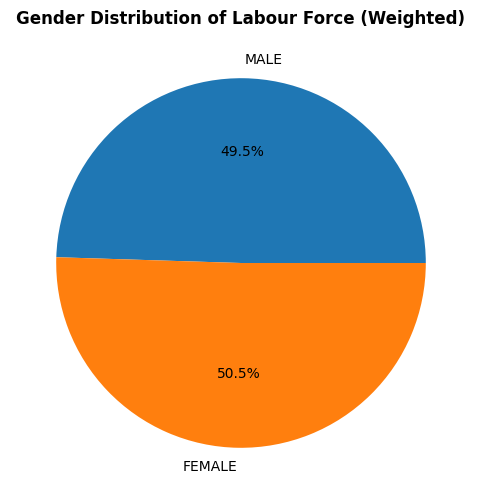

In [24]:
#3. Gender distribution
gender_weighted = im_data.groupby('gender')['popw'].sum()

plt.figure(figsize=(6,6))
plt.pie(gender_weighted, labels=gender_weighted.index, autopct='%1.1f%%')
plt.title('Gender Distribution of Labour Force (Weighted)', weight='bold')
plt.savefig('images/chart3_gender_distribution_weighted.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1220/373699254.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('sector')['popw']


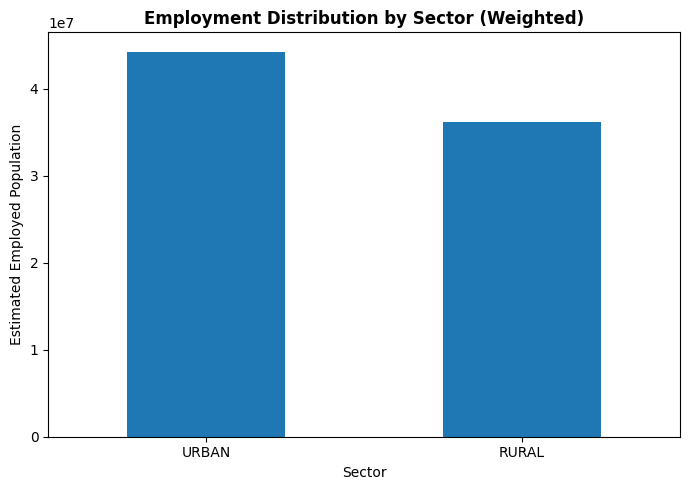

In [25]:
#Employment by sector
employment_by_sector = (
    im_data[im_data['employment_status'] == 'Employed']
    .groupby('sector')['popw']
    .sum()
)

plt.figure(figsize=(7,5))
employment_by_sector.plot(kind='bar')
plt.title('Employment Distribution by Sector (Weighted)', weight='bold')
plt.xlabel('Sector')
plt.ylabel('Estimated Employed Population')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('images/chart4_employment_by_sector_weighted.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1220/996060359.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby('gender')['popw']


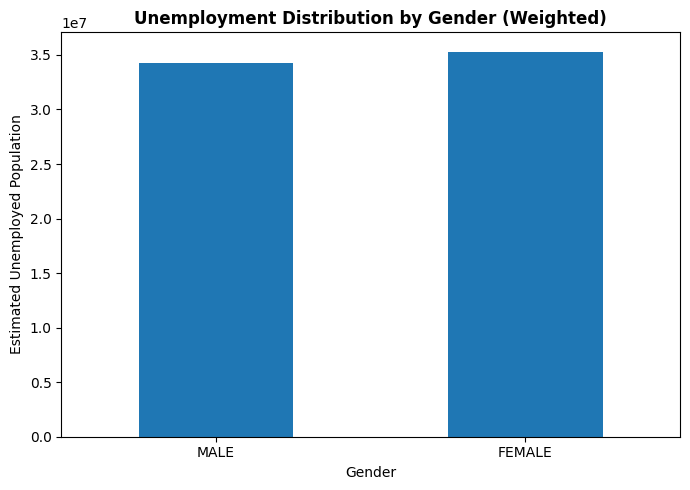

In [26]:
#Unemployment by gender
unemp_gender = (
    im_data[im_data['employment_status'] == 'Unemployed']
    .groupby('gender')['popw']
    .sum()
)

plt.figure(figsize=(7,5))
unemp_gender.plot(kind='bar')
plt.title('Unemployment Distribution by Gender (Weighted)', weight='bold')
plt.xlabel('Gender')
plt.ylabel('Estimated Unemployed Population')
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('images/chart5_unemployment_by_gender_weighted.png', dpi=300, bbox_inches='tight')
plt.show()

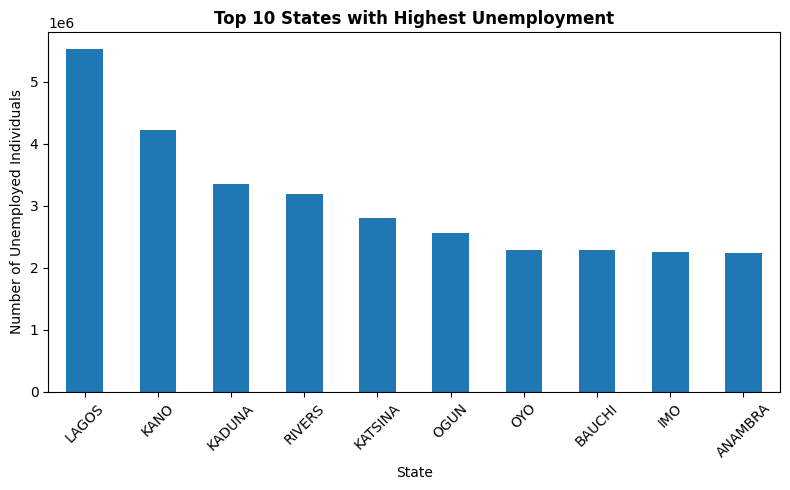

In [27]:
#Top 10 states by unemployment
top_states.plot(kind='bar', figsize=(8,5))
plt.title('Top 10 States with Highest Unemployment', weight='bold')
plt.xlabel('State')
plt.ylabel('Number of Unemployed Individuals')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('images/chart6_top 10 states by unemployment.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1220/2736744163.py:2: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  edu_emp = pd.pivot_table(


<Figure size 1500x1000 with 0 Axes>

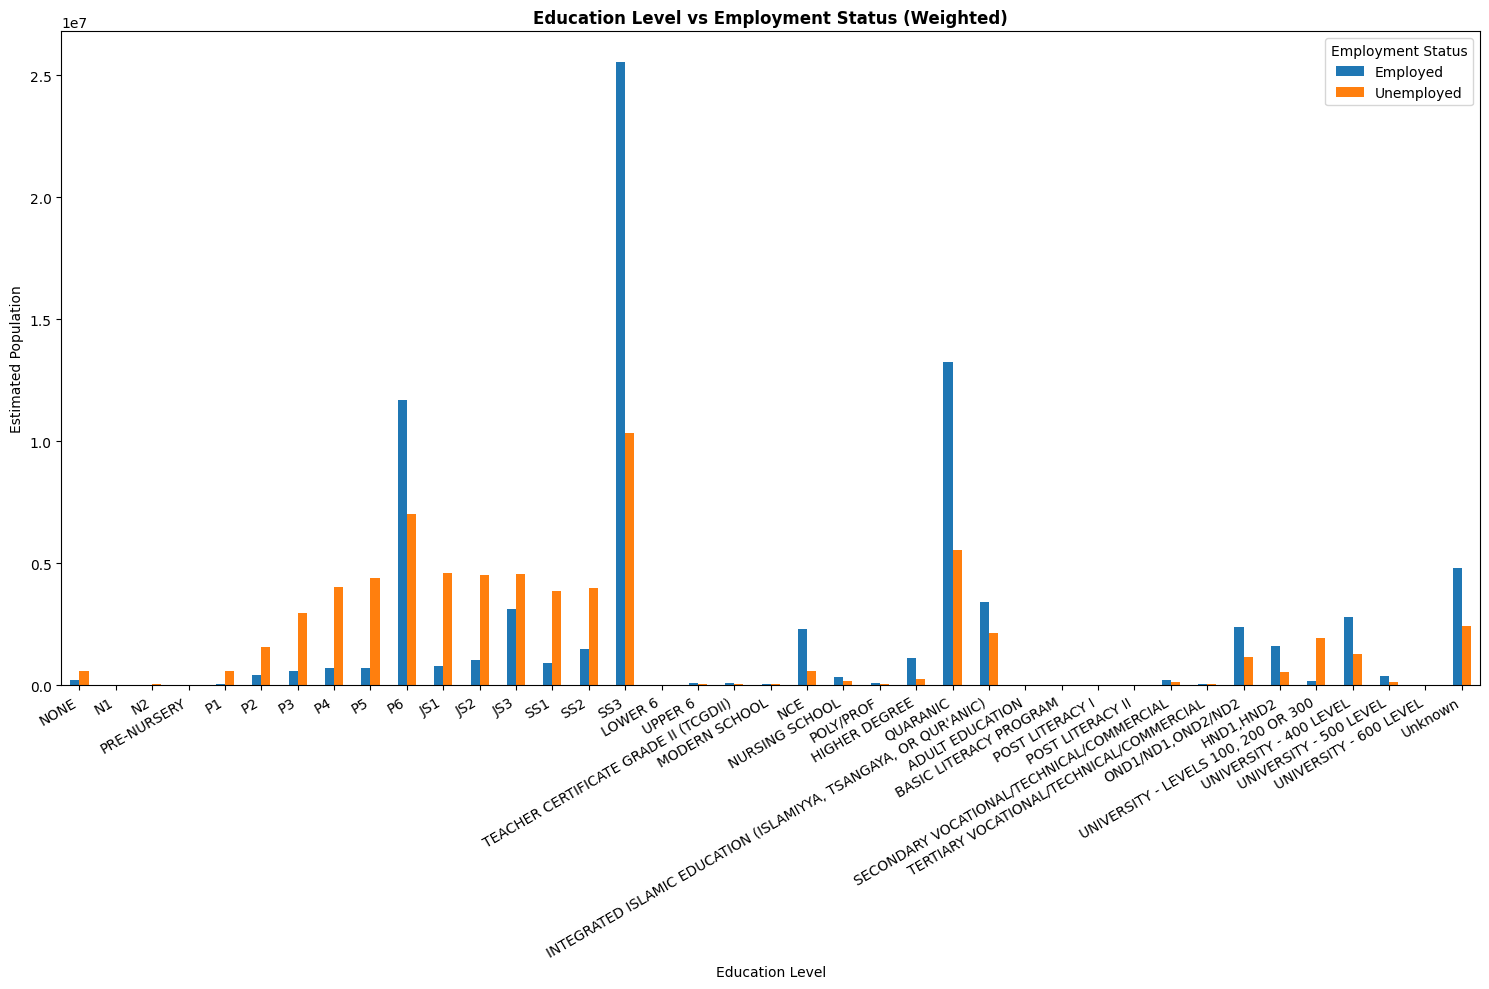

In [28]:
# Education level vs employment status
edu_emp = pd.pivot_table(
    im_data,
    values='popw',
    index='education_level',
    columns='employment_status',
    aggfunc='sum'
)

plt.figure(figsize=(15,10))
edu_emp.plot(kind='bar', figsize=(15,10))
plt.title('Education Level vs Employment Status (Weighted)', weight='bold')
plt.xlabel('Education Level')
plt.ylabel('Estimated Population')
plt.xticks(rotation=30, ha='right')
plt.legend(title='Employment Status')
plt.tight_layout()
plt.savefig('images/chart7_education_vs_employment_weighted.png', dpi=300, bbox_inches='tight')
plt.show()

/tmp/ipykernel_1220/1748377506.py:8: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  age_emp = pd.pivot_table(


<Figure size 1000x600 with 0 Axes>

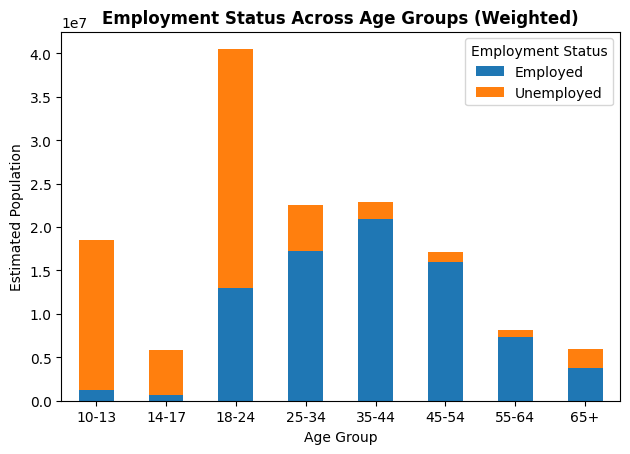

In [29]:
#Age group vs employment status
# Create age groups
bins = [10,13, 14, 24, 34, 44, 54, 64, 100]
labels = ['10-13','14-17', '18-24', '25-34', '35-44', '45-54', '55-64', '65+']
im_data['age_group'] = pd.cut(im_data['age'], bins=bins, labels=labels)

# Weighted pivot
age_emp = pd.pivot_table(
    im_data,
    values='popw',
    index='age_group',
    columns='employment_status',
    aggfunc='sum'
)

plt.figure(figsize=(10,6))
age_emp.plot(kind='bar', stacked=True)
plt.title('Employment Status Across Age Groups (Weighted)', weight='bold')
plt.xlabel('Age Group')
plt.ylabel('Estimated Population')
plt.xticks(rotation=0)
plt.legend(title='Employment Status')
plt.tight_layout()
plt.savefig('images/chart8_age_group_employment_weighted.png', dpi=300, bbox_inches='tight')
plt.show()

## **Narrative Sumary**

Nigeria’s labour market data reveals three key insights with important implications for policymakers and business leaders.

First, unemployment remains widespread, with the weighted results showing that  a substantial portion of the working-age population is either unemployed or possibly engaged in unstable forms of work. Notably, over 80% of employed
individuals are self-employed, suggesting that formal job opportunities are limited and many people rely on informal or survival-based activities. This raises concerns about income stability and productivity, and highlights the need to stimulate formal sector job creation.

Second, youth unemployment is particularly critical, with a weighted unemployment rate of approximately 38% (equivalent to about 15.3 million persons)among individuals aged 18 to 35. This indicates a structural challenge in integrating young people into the workforce. Without targeted interventions such as skills development, vocational training, and entry-level job programs, this demographic pressure could persist and impact long-term economic growth.

Third, unemployment is unevenly distributed across regions, with states such as Lagos, Kano, and Kaduna accounting for large shares of the unemployed population. This suggests that economic opportunities are concentrated and unevenly accessible. Policymakers should prioritize region-specific strategies, including infrastructure investment and support for local industries, to promote more balanced economic development.